In [1]:
# 1. IMPORTAMOS LIBRERIAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# IMPORTAMOS EL DATASET

df = pd.read_csv("../../Base_de_datos.csv")
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,"88,768094",...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,"95,227787",...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,"47,613894",...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,"95,227787",...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,"95,227787",...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  str    
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

De las variables analizadas vemos a grandes rasgos:
* que de las 23, 7 poseen valores nulos
* binaria: pago_atiempo
* tipo_credito: parece ser una variable categorica ordinal, deberiamos ver a travez de unique su comportamiento
* plazo_meses: podria ser categorica ordinal o como aparece en el tabla int, habria que evaluar con unique tambien
* categoricas: tipo_laboral, tendencia_ingresos (ordinal)
* variables mal tipadas como str (se corrigen para este análisis, ver Avance 2 para modificacion definitiva):
         puntaje (→ numérica), 
         fecha_prestamo (→ temporal)

In [4]:
df["tipo_credito"].unique()

array([ 7,  4,  9, 10,  6, 68])

In [5]:
df['tipo_credito'].value_counts().sort_index()

tipo_credito
4     7747
6       21
7        2
9     2876
10     116
68       1
Name: count, dtype: int64

A partir del análisis de la variable tipo_credito, observamos:
* 6 valores distintos: 4, 6, 7, 9, 10, 68
* Dos categorías concentran casi todo el dataset: 4 (7747 casos) y 9 (2876 casos)
* Dos categorías minoritarias pero con volumen real: 6 (21 casos) y 10 (116 casos)
* El valor 68 es sospechoso de ser un error de carga/tipeo: además de tener muy baja frecuencia (1 caso), rompe la escala del resto de los valores (4 a 10) — hipótesis a confirmar en Avance 2, no un hecho verificado
* El valor 7 tiene baja frecuencia (2 casos) pero, a diferencia del 68, encaja dentro del rango esperado de la escala — lo tratamos como caso raro a monitorear, no como error evidente
* Llama la atención la ausencia de los códigos 5 y 8 en la escala (4, 6, 7, 9, 10) — abre la duda de si la codificación es correlativa, si esos tipos no se otorgaron en el período de la muestra, o si corresponden a categorías discontinuadas. No tenemos un diccionario de datos que lo confirme.
* Limitación del análisis: no contamos con documentación que explique el significado de cada código de tipo_credito

In [6]:
df['plazo_meses'].unique()

array([10,  6, 11, 12,  3,  8,  5,  2,  7,  9, 24, 18, 36,  4, 20, 30, 90,
       48])

In [7]:
df['plazo_meses'].value_counts().sort_index()

plazo_meses
2      174
3      107
4       66
5      232
6     3326
7       22
8      526
9      650
10    1520
11     324
12    2658
18     275
20      14
24     464
30      18
36     385
48       1
90       1
Name: count, dtype: int64

A partir del análisis de la variable plazo_meses, observamos:
* 18 valores distintos, con una fuerte concentración en ciertos plazos: 6 (3326 casos), 12 (2658 casos), 9 (650 casos), 10 (1520 casos) y 24 (464 casos) concentran la gran mayoría del dataset
* Los saltos entre valores no siguen una progresión proporcional (ej: de 12 a 18 hay 6 meses de diferencia, pero de 18 a 20 solo hay 2) — esto sugiere que son plazos comerciales específicos ofrecidos por la financiera, **no una escala matemática continua**. A confirmar si se trata de variable numérica discreta o categórica ordinal.
* Dos valores con 1 sola aparición cada uno: 48 y 90 meses. A diferencia del caso de tipo_credito (donde 68 es un código arbitrario sin referencia externa posible), acá sí podemos evaluar plausibilidad real: 48 meses (4 años) es un plazo común en créditos de consumo, mientras que 90 meses (7.5 años) es bastante más inusual — aunque ninguno es imposible en sí mismo.
* En conjunto, estos dos outliers de plazo_meses son más plausibles que el 68 de tipo_credito, precisamente porque representan una cantidad con significado real (meses) y no un código arbitrario — no descartamos que sean errores de carga, pero la evidencia para sospechar es más débil que en el caso anterior.

In [8]:
df.describe()

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,5.411131,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
std,2.338279,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668
min,4.000000,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,4.000000,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,68.000000,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000


**Analisis superficial de la funcion describe**

huella_consulta: mean (4.23) y std (3.06) del mismo orden de magnitud — dispersión moderada. Sin nulos

saldo_mora: mean muy baja (7.75) con std altísimo (226, ~29x la media) — patrón típico de una variable donde la mayoría de los casos están en 0 (sin mora) y una minoría concentra valores altos. A revisar con prioridad. Con nulos (156) — a definir en el tratamiento de nulos si un NaN significa "sin mora" o "dato no registrado"

saldo_total: std (106.270) ~2.3x la media (45.937) — dispersión considerable pero mucho menor que en saldo_mora. Con nulos (156)

saldo_principal: std (71.242) ~1.8x la media (40.346) — dispersión moderada-alta. Con nulos (405)

saldo_mora_codeudor: el caso más extremo de todo el dataset hasta ahora — mean casi cero (0.26) con std de 21.77 (~84x la media). Mismo patrón que saldo_mora, agravado: la enorme mayoría de codeudores no tendría mora, con muy pocos casos concentrando valores altos. A revisar con prioridad. Con nulos (590) — misma duda que saldo_mora sobre el significado del NaN

creditos_sectorFinanciero / creditos_sectorCooperativo / creditos_sectorReal: means bajas (2.78, 0.27 y 1.30 respectivamente) con std relativamente altos en proporción — sugiere concentración de créditos en pocos clientes con varios créditos vigentes por sector, mientras la mayoría tiene pocos o ninguno.Sin nulos

promedio_ingresos_datacredito: std (2.144.116) similar en magnitud a la media (2.005.156) — dispersión moderada. Con nulos (2930) — la columna con más valores faltantes del dataset, a priorizar en el tratamiento de nulos

Pago_atiempo (target): mean 0.95, std 0.21 — variable binaria con fuerte desbalance de clases: aproximadamente 95% de los casos en una clase. Relevante para el Avance 2, donde el desbalance puede requerir técnicas específicas de modelado. Sin nulos

## TRATAMIENTO DE NULOS Y OUTLIERS

In [9]:
#Cantidad de **NULOS** por variable

nulos = df.isnull().sum()
nulos[nulos != 0]

puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64

### Comenzamos tratando las variables resultantes en la tabla de nulos con sus outliers

In [10]:
df["puntaje_datacredito"].describe()

count    10757.000000
mean       780.790834
std        104.878031
min         -7.000000
25%        757.000000
50%        791.000000
75%        825.000000
max        999.000000
Name: puntaje_datacredito, dtype: float64

In [11]:
# la variable posee un valor imposible detectado anteriormente, que será tratado como NAN, para luego tratarlos todos juntos.
df.loc[df['puntaje_datacredito'] == -7, 'puntaje_datacredito'] = np.nan

In [12]:
df['puntaje_datacredito'].isnull().sum()

np.int64(7)

In [13]:
df['puntaje_datacredito'].mean()

np.float64(780.8640758646337)

Comparando la media antes (780.79) y después (780.86) de tratar el valor imposible como nulo, la diferencia es mínima (0.07) — en este caso puntual, el -7 no distorsionó demasiado la media. Sin embargo, decidimos imputar con la mediana: es el criterio más robusto en general frente a valores atípicos, independientemente de que en esta variable el impacto haya sido chico. Con datos futuros (por ejemplo, si aparecieran valores imposibles más extremos), la mediana sigue siendo la opción más segura por default.

In [14]:
mediana = df['puntaje_datacredito'].median()
df['puntaje_datacredito'] = df['puntaje_datacredito'].fillna(mediana)

In [15]:
df['puntaje_datacredito'].isnull().sum()

np.int64(0)

In [16]:
df["saldo_mora"].describe()

count    10607.000000
mean         7.746017
std        225.955117
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      12534.000000
Name: saldo_mora, dtype: float64

In [17]:
df["saldo_mora"].unique()


array([    0.,   132.,   366.,  5721.,    67.,  2145.,   238.,    63.,
          nan,  4379.,   866.,  1584.,  2119.,  1463.,    30.,   829.,
          50.,   163.,   106.,   631.,   115.,   336.,  2291.,  4973.,
       10081.,   105.,    45.,   148.,    29.,   116.,   222.,   202.,
         102.,    17.,    78.,    46.,   407.,   484.,   127.,    70.,
       10327.,  5096.,    61., 12534.,    73.,   802.,  6709.,   470.,
         236.,    79.,  2082.,   576.,   582.,   234.,  1153.,   172.])

In [18]:
df['saldo_mora'] = df['saldo_mora'].fillna(0)

In [20]:
df["saldo_mora"].isnull().sum()


np.int64(0)

In [21]:
df["saldo_total"].describe()

count    1.060700e+04
mean     4.593741e+04
std      1.062698e+05
min      0.000000e+00
25%      2.898000e+03
50%      1.617800e+04
75%      5.298200e+04
max      5.116066e+06
Name: saldo_total, dtype: float64

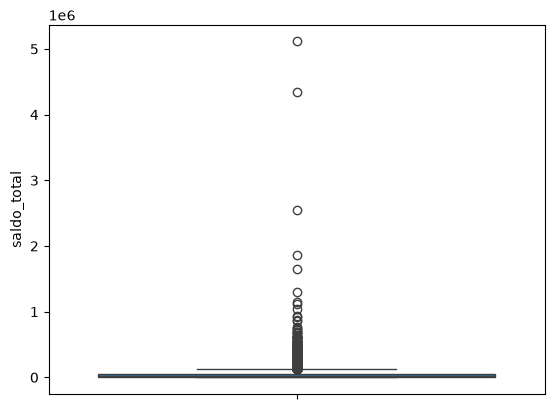

In [24]:
sns.boxplot(data=df, y='saldo_total')
plt.show()

descartamos presencia outliers, presenta una cola larga de valores. Usaremos la mediana para reemplazar los valores nulos.

In [25]:
mediana = df['saldo_total'].median()
df['saldo_total'] = df['saldo_total'].fillna(mediana)

In [27]:
df['saldo_total'].isnull().sum()

np.int64(0)

In [28]:
df["saldo_principal"].describe()

count    1.035800e+04
mean     4.034617e+04
std      7.124244e+04
min      0.000000e+00
25%      2.690000e+03
50%      1.444250e+04
75%      4.763225e+04
max      1.562285e+06
Name: saldo_principal, dtype: float64

In [30]:
mediana_principal = df['saldo_principal'].median()
df['saldo_principal'] = df['saldo_principal'].fillna(mediana_principal)

In [31]:
df['saldo_principal'].isnull().sum()

np.int64(0)

In [32]:
df["saldo_mora_codeudor"].describe()

count    10173.000000
mean         0.260002
std         21.772917
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2145.000000
Name: saldo_mora_codeudor, dtype: float64

In [33]:
df['saldo_mora_codeudor'] = df['saldo_mora_codeudor'].fillna(0)

In [34]:
df['saldo_mora_codeudor'].isnull().sum()

np.int64(0)

promedio_ingresos_datacredito

In [36]:
# Guardamos la distribución original (sin nulos)
original = df['promedio_ingresos_datacredito'].dropna()

# Simulamos la imputación con mediana, sin tocar el df todavía
mediana_ingresos = df['promedio_ingresos_datacredito'].median()
imputado = df['promedio_ingresos_datacredito'].fillna(mediana_ingresos)

# Comparamos estadísticas
print("Original:")
print(original.describe())
print("\nImputado:")
print(imputado.describe())

Original:
count    7.833000e+03
mean     2.005157e+06
std      2.144116e+06
min      0.000000e+00
25%      9.251570e+05
50%      1.204496e+06
75%      2.231859e+06
max      3.810658e+07
Name: promedio_ingresos_datacredito, dtype: float64

Imputado:
count    1.076300e+04
mean     1.787194e+06
std      1.863501e+06
min      0.000000e+00
25%      9.618850e+05
50%      1.204496e+06
75%      1.705770e+06
max      3.810658e+07
Name: promedio_ingresos_datacredito, dtype: float64


Comparando ambas distribuciones, una habiendo reemplazado los nulos por la mediana y otro sin el reemplazo, se puede observar que esta alternativa modificaria notoriamente la distribucion haciendola mas ancha en el centro.

In [40]:
# agregamos semilla de reproducibilidad
np.random.seed(42)

# Cuántos nulos hay que rellenar
n_nulos = df['promedio_ingresos_datacredito'].isnull().sum()

# Tomamos valores al azar de los datos reales (no nulos), con reemplazo
valores_random = df['promedio_ingresos_datacredito'].dropna().sample(n=n_nulos, replace=True).values

# Rellenamos los nulos con esos valores aleatorios
df.loc[df['promedio_ingresos_datacredito'].isnull(), 'promedio_ingresos_datacredito'] = valores_random

In [41]:
df["promedio_ingresos_datacredito"].isnull().sum()

np.int64(0)

tendencia_ingresos

In [42]:
n_nulos_tendencia = df['tendencia_ingresos'].isnull().sum()
valores_random_tendencia = df['tendencia_ingresos'].dropna().sample(n=n_nulos_tendencia, replace=True, random_state=42).values
df.loc[df['tendencia_ingresos'].isnull(), 'tendencia_ingresos'] = valores_random_tendencia

In [43]:
df['tendencia_ingresos'].isnull().sum()

np.int64(0)

In [45]:
# Corroboramos en todo el data frame
df.isnull().sum()

tipo_credito                     0
fecha_prestamo                   0
capital_prestado                 0
plazo_meses                      0
edad_cliente                     0
tipo_laboral                     0
salario_cliente                  0
total_otros_prestamos            0
cuota_pactada                    0
puntaje                          0
puntaje_datacredito              0
cant_creditosvigentes            0
huella_consulta                  0
saldo_mora                       0
saldo_total                      0
saldo_principal                  0
saldo_mora_codeudor              0
creditos_sectorFinanciero        0
creditos_sectorCooperativo       0
creditos_sectorReal              0
promedio_ingresos_datacredito    0
tendencia_ingresos               0
Pago_atiempo                     0
dtype: int64

In [46]:
# Verificamos duplicados
df.duplicated().sum()

np.int64(0)

Sin duplicados

In [50]:
# Procedemos a evaluar los EXTREMOS del resto de las variables: edad_cliente, salario_cliente, total_otros_prestamos (las dos con la alarma fuerte, std ~20x la media),
# cuota_pactada y cant_creditosvigentes.

df['edad_cliente'].unique()

array([ 42,  60,  36,  48,  44,  32,  68,  31,  45,  61,  58,  66,  52,
        43,  34,  50,  49,  46,  62,  56,  40,  51,  63,  57,  39,  53,
        55,  59,  38,  41,  47,  64,  65,  20,  37,  67,  54,  35,  33,
        69,  26,  23,  27,  21,  30,  29,  22,  25,  28,  24,  19, 122,
       121, 123])

In [64]:
print((df['edad_cliente'] == 121).sum())
print((df['edad_cliente'] == 122).sum())
print((df['edad_cliente'] == 123).sum())


4
144
2


In [ ]:
# ya sabiendo que tenemos valores extremos: 122, 121 y 123,  primero

In [69]:
print(df['edad_cliente'].describe())
print(df['edad_cliente'].mode())

count    10763.000000
mean        43.948620
std         15.060877
min         19.000000
25%         33.000000
50%         42.000000
75%         53.000000
max        123.000000
Name: edad_cliente, dtype: float64
0    40
Name: edad_cliente, dtype: int64


Media (43.95), mediana (42) y moda (40) están muy próximas entre sí en la distribución original. Esto 
sugiere que, al reemplazar los ~150 valores atípicos (121, 122, 123) por la mediana, el impacto sobre 
la forma general de la distribución sería mínimo — no se trata de insertar un valor "ajeno" al 
comportamiento típico de la variable, sino uno que ya está en línea con su tendencia central. Se eligió 
la mediana, de todas formas, por ser la medida más robusta frente a valores atípicos en general.

In [71]:
df['edad_cliente'] = df['edad_cliente'].replace([121, 122, 123], np.nan)
mediana_edad = df['edad_cliente'].median()
df['edad_cliente'] = df['edad_cliente'].fillna(mediana_edad)
print(df["edad_cliente"].describe())

count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64


In [72]:
df["salario_cliente"].describe()

count    1.076300e+04
mean     1.721643e+07
std      3.554767e+08
min      0.000000e+00
25%      2.000000e+06
50%      3.000000e+06
75%      4.875808e+06
max      2.200000e+10
Name: salario_cliente, dtype: float64

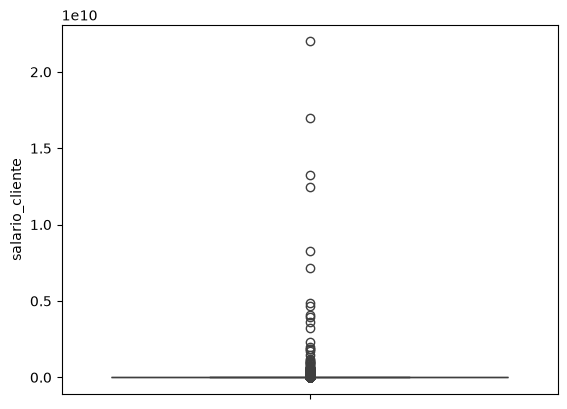

In [74]:
sns.boxplot(data=df, y='salario_cliente')
plt.show()

In [75]:
df['salario_cliente'].nlargest(10)

5735    22000000000
2866    16991100000
7014    13258352050
7043    12450806583
7041     8252584000
7070     7170914725
7053     4857353453
7116     4663274549
7110     4067140000
7058     3979311000
Name: salario_cliente, dtype: int64

In [76]:
(df['salario_cliente'] > 100000000).sum()

np.int64(74)

In [77]:
df.loc[df['salario_cliente'] > 100000000, 'salario_cliente'] = np.nan
mediana_salario = df['salario_cliente'].median()
df['salario_cliente'] = df['salario_cliente'].fillna(mediana_salario)

In [78]:
(df['salario_cliente'] > 100000000).sum()

np.int64(0)

salario_cliente: detectamos valores absurdamente altos (hasta 22.000.000.000, cuando la media general 
de la columna era de ~17.200.000) — un error evidente del dataset, no casos plausibles de salarios 
individuales. Establecimos un umbral de 100.000.000, bastante por encima del 75% real de la distribución 
(~4.875.808), para capturar con confianza solo los valores erróneos sin afectar salarios altos pero 
creíbles. 74 filas (aproximadamente 0.69% del dataset) superaban ese umbral. Fueron convertidas a nulo y 
reemplazadas por la mediana de los valores válidos, confirmando con un nuevo conteo que ya no quedan 
valores por encima del umbral.

In [79]:
df['total_otros_prestamos'].nlargest(10)

7043    6787675263
7070    4974345404
7014    4316463703
7110    3918433000
7058    3758729000
7041    3147612000
7033    1995279822
7025    1715477430
7124    1520119000
7973    1500000000
Name: total_otros_prestamos, dtype: int64

In [81]:
df['total_otros_prestamos'].describe()

count    1.076300e+04
mean     6.238870e+06
std      1.184183e+08
min      0.000000e+00
25%      5.000000e+05
50%      1.000000e+06
75%      2.000000e+06
max      6.787675e+09
Name: total_otros_prestamos, dtype: float64

In [82]:
(df['total_otros_prestamos'] > 100000000).sum()

np.int64(44)

In [83]:
df.loc[df['total_otros_prestamos'] > 100000000, 'total_otros_prestamos'] = np.nan
mediana_otros_prestamos = df['total_otros_prestamos'].median()
df['total_otros_prestamos'] = df['total_otros_prestamos'].fillna(mediana_otros_prestamos)

In [84]:
(df['total_otros_prestamos'] > 100000000).sum()

np.int64(0)

total_otros_prestamos: mismo patrón de error que salario_cliente — valores hasta 6.787.675.263, muy por 
encima del 75% real (2.000.000). Umbral de 100.000.000, 44 filas afectadas (~0.41%), convertidas a nulo 
y reemplazadas por la mediana.

In [86]:
df['cuota_pactada'].nlargest(10)

7133     3816752
5028     2671342
7032     2525162
7108     2439394
7107     2355457
315      2219827
5430     2199518
7064     2165346
1063     2156598
10707    2140141
Name: cuota_pactada, dtype: int64

In [87]:
df['cuota_pactada'].describe()

count    1.076300e+04
mean     2.436174e+05
std      2.104937e+05
min      2.394400e+04
25%      1.210415e+05
50%      1.828630e+05
75%      2.878335e+05
max      3.816752e+06
Name: cuota_pactada, dtype: float64

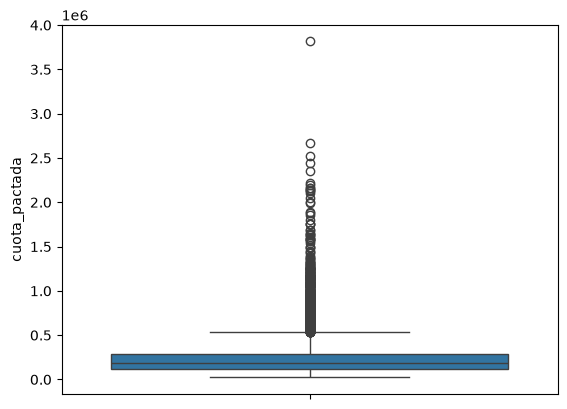

In [88]:
sns.boxplot(data=df, y='cuota_pactada')
plt.show()

In [89]:
(df['cuota_pactada'] > 1000000).sum()

np.int64(154)

In [90]:
df.loc[df['cuota_pactada'] > 1000000, ['cuota_pactada', 'capital_prestado', 'plazo_meses']].sort_values('cuota_pactada', ascending=False)

,cuota_pactada,capital_prestado,plazo_meses
7133,3816752,41444153,10
5028,2671342,22502400,8
7032,2525162,26208019,10
7108,2439394,28779582,11
7107,2355457,25657456,10
...,...,...,...
4681,1009962,6790968,6
5235,1007650,6728266,6
464,1004202,7346830,6
3779,1002428,11250755,10


cuota_pactada: a primera vista, valores entre 2.000.000 y 3.816.752 parecían demasiado altos para una 
cuota mensual (muy por encima del 75% real, ~287.833). Sin embargo, al cruzar estas 154 filas con 
capital_prestado y plazo_meses, se confirma consistencia matemática: las cuotas altas corresponden a 
capitales prestados altos (14-41 millones) pagados en plazos cortos (2-12 meses) — por ejemplo, 
3.816.752 de cuota con 41.444.153 de capital a 10 meses (≈4.144.415/mes esperado, en línea con el valor 
real). No se identifican outliers; se trata de la cola alta y coherente de la distribución, no de 
errores de carga. Sin tratamiento aplicado.

In [91]:
df["cant_creditosvigentes"].describe()

count    10763.000000
mean         5.726749
std          3.977162
min          0.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         62.000000
Name: cant_creditosvigentes, dtype: float64

In [95]:
df['cant_creditosvigentes'].value_counts().sort_index().tail(10)

cant_creditosvigentes
29    2
30    2
31    2
32    2
33    1
34    1
35    2
36    1
38    1
62    1
Name: count, dtype: int64

In [96]:
df['cant_creditosvigentes'] = df['cant_creditosvigentes'].replace(62, np.nan)
mediana_creditos = df['cant_creditosvigentes'].median()
df['cant_creditosvigentes'] = df['cant_creditosvigentes'].fillna(mediana_creditos)

cant_creditosvigentes: se detectó un salto abrupto en la distribución — valores de 29 a 38 siguen una 
progresión continua y coherente (1-2 casos cada uno), pero el máximo salta directamente a 62, sin ningún 
valor intermedio entre 39 y 61. Se trata de 1 solo caso aislado, consistente con el patrón de error ya 
visto en otras variables del dataset. Fue convertido a nulo y reemplazado por la mediana (5).

In [98]:
df['tipo_credito'] = df['tipo_credito'].replace(68, np.nan)
moda_credito = df['tipo_credito'].mode()[0]
df['tipo_credito'] = df['tipo_credito'].fillna(moda_credito)

In [99]:
df['tipo_credito'].describe()

count    10763.000000
mean         5.405184
std          2.259136
min          4.000000
25%          4.000000
50%          4.000000
75%          9.000000
max         10.000000
Name: tipo_credito, dtype: float64

tipo_credito: el valor atípico 68 fue convertido a nulo y reemplazado por la moda (4), unificando el 
criterio de tratamiento con el resto de las variables numéricas. Queda pendiente para el Avance 2 la 
duda sobre la ausencia de los códigos 5 y 8 en la escala observada.

In [101]:
df['capital_prestado'].nlargest(5)

7133    41444153
5897    28800000
7108    28779582
7032    26208019
7107    25657456
Name: capital_prestado, dtype: int64

Verificación rápida de capital_prestado y las variables creditos_sector (Financiero, Cooperativo, Real): 
capital_prestado no muestra saltos abruptos en su cola superior (confirmado además indirectamente al 
validar cuota_pactada), y las tres variables de sector tienen rangos acotados (máximos de 51, 13 y 25) 
sin evidencia de errores de magnitud. No se aplica tratamiento.